# CNN vs FNN for MNIST dataset

### Load and prepare MNIST

In [120]:
# import tensorflow libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical



In [105]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [106]:
#check the dimension of the dataset
print (X_train.shape)
print (y_train.shape)

(60000, 28, 28)
(60000,)


In [107]:
#check for test dataset
print (X_test.shape)
print (y_test.shape)

(10000, 28, 28)
(10000,)


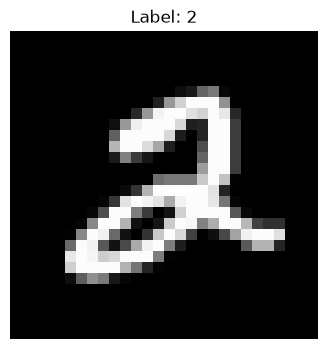

In [108]:
#Visualise sample image
plt.figure(figsize=(4,4))
plt.imshow(X_train[5], cmap='gray')
plt.title(f'Label: {y_train[5]}')
plt.axis('off')
plt.show()


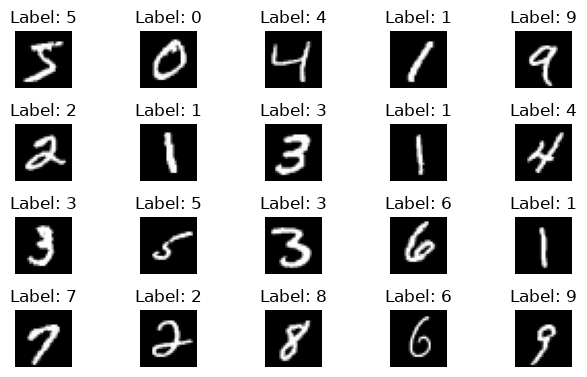

In [109]:
#visualise first 20 handwritten image
plt.Figure(figsize=(10,5))

for i in range(20):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f'Label: {y_train[i]}')
    plt.axis('off')
    
plt.tight_layout()   
plt.show()

### Model Preprocessing

In [110]:
# Normalisation
X_train = X_train/255.0
X_test = X_test/255.0

In [111]:
y_test.shape

(10000,)

In [112]:
#OneHot encoding on the labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [113]:
y_test.shape

(10000, 10)

## Building FNN

In [114]:
fnn_model =Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

### Compiling the model

In [115]:
# model training configuration
fnn_model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

### Model training

In [116]:
fnn_history = fnn_model.fit(
    X_train, y_train,
    epochs = 10,
    batch_size = 32,
    validation_split = 0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9162 - loss: 0.2917 - val_accuracy: 0.9573 - val_loss: 0.1566
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9607 - loss: 0.1343 - val_accuracy: 0.9668 - val_loss: 0.1151
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9724 - loss: 0.0916 - val_accuracy: 0.9685 - val_loss: 0.1055
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9797 - loss: 0.0675 - val_accuracy: 0.9694 - val_loss: 0.0989
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9839 - loss: 0.0522 - val_accuracy: 0.9718 - val_loss: 0.0922
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9879 - loss: 0.0401 - val_accuracy: 0.9727 - val_loss: 0.0942
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9902 - loss: 0.0322 - val_accuracy: 0.9720 - val_loss: 0.0997
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9924 - loss: 0.0254 - 

### Model evaluation

In [117]:
fnn_loss, fnn_accuracy = fnn_model.evaluate(X_test, y_test)
print ('FNN Test Accuracy:', fnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step - accuracy: 0.9762 - loss: 0.0826
FNN Test Accuracy: 0.9761999845504761


### Making predictions


In [118]:
predictions = fnn_model.predict(X_test)
predicted_digit = np.argmax(predictions[2])
true_digit = np.argmax(y_test[2])

print(f'Predicted: {predicted_digit}')
print(f'Actual: {true_digit}')


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step
Predicted: 1
Actual: 1


## Building CNN model

In [119]:
# REshape for CNN
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_test_cnn = X_test.reshape(-1,28,28,1)

### cnn model

In [122]:
cnn_model = Sequential([
   Input (shape=(28,28,1)),
   Conv2D(64,(3,3), activation='relu'),
   MaxPooling2D((2,2)),
   Flatten(),
   Dense(64, activation='relu'),
   Dense(10, activation='softmax')
])  

### compile the CNN model

In [129]:
cnn_model.compile(
    optimizer ='adam',
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

### Train CNN

In [131]:
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    epochs = 10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9953 - loss: 0.0138 - val_accuracy: 0.9849 - val_loss: 0.0575
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9962 - loss: 0.0111 - val_accuracy: 0.9853 - val_loss: 0.0582
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9971 - loss: 0.0080 - val_accuracy: 0.9869 - val_loss: 0.0588
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9977 - loss: 0.0067 - val_accuracy: 0.9848 - val_loss: 0.0666
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9983 - loss: 0.0054 - val_accuracy: 0.9859 - val_loss: 0.0611
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9985 - loss: 0.0048 - val_accuracy: 0.9842 - val_loss: 0.0745
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9986 - loss: 0.0045 - val_accuracy: 0.9837 - val_loss: 0.0777
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9984 - loss: 0.0048 -

### Evaluating CNN model


In [132]:
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test)
print('CNN accuracy', cnn_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9860 - loss: 0.0703
CNN accuracy 0.9860000014305115


### Comparing accuracy of both models


In [139]:
print(f'FNN model accuracy:', fnn_accuracy)
print(f'CNN model accuracy:', cnn_accuracy)


FNN model accuracy: 0.9761999845504761
CNN model accuracy: 0.9860000014305115


- CNN scores higher than FNN because FNN see pixels as flat numbers, but CNN sees edges, shapes, and digits making it understands spatial patterns.

- FNN flattens image which could lead to loss of structure while CNN understands the image local patterns leading to global understanding of the image.

## Training curves comparison (FNN vs CNN)

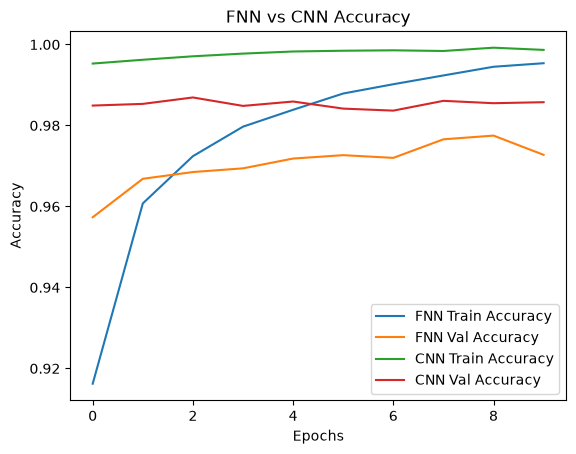

In [140]:
import matplotlib.pyplot as plt

# Accuracy comparison
plt.figure()

plt.plot(fnn_history.history['accuracy'], label='FNN Train Accuracy')
plt.plot(fnn_history.history['val_accuracy'], label='FNN Val Accuracy')

plt.plot(cnn_history.history['accuracy'], label='CNN Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Accuracy')

plt.title('FNN vs CNN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

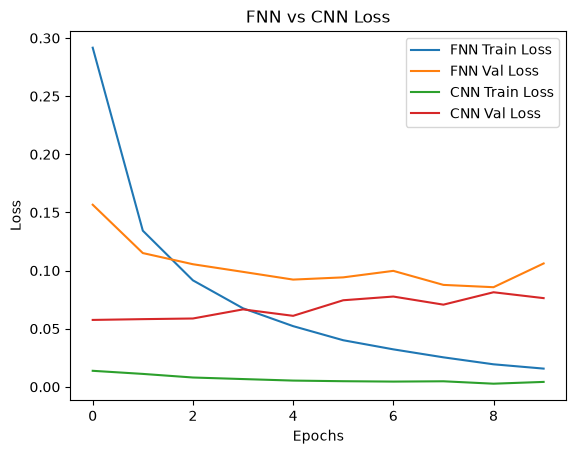

In [ ]:
plt.figure()
#Loss accuracy
plt.plot(fnn_history.history['loss'], label='FNN Train Loss')
plt.plot(fnn_history.history['val_loss'], label='FNN Val Loss')

plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')

plt.title('FNN vs CNN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

The accuracy curves show that both models achieve high training accuracy, however, the CNN consistently outperforms the FNN in validation accuracy. The FNN exhibits signs of overfitting, as its training accuracy continues to increase while validation accuracy plateaus. In contrast, the CNN maintains both high and stable training and validation accuracy, indicating better generalisation. This demonstrates the advantage of CNNs in capturing spatial features in image data. Similar behaviour is observed on the loss curve. The loss curve further confirmed the overfitting observed for FNN model